## Small notebook to test a trained model

In [14]:
# Imports
import torch
import matplotlib.pyplot as plt
from pathlib import Path

import sys
import os
sys.path.append(os.path.abspath(".."))

from models.flow_matching import FlowModel, NumericalODESolver
from data.point_clouds import PointCloudGenerator

In [ ]:
# Define the model and load the weights
CHECKPOINT_PATH = Path("../../checkpoints/MultiLayerPerceptron_weigths_step_50000.pt").resolve()

# Architecture must match the config the checkpoint was trained with (preferences/model/mlp.yaml)
model = FlowModel(in_features=3, hidden_features=128, out_features=2)

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
model.load_state_dict(checkpoint["model"])
model.eval()

FlowModel(
  (model): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [16]:
# Define the ODE solver
solver = NumericalODESolver(model=model, solver="euler", integration_steps=100, return_trajectory=False)

In [24]:
# Draw some data from p0 and integrate using the solver
data_generator = PointCloudGenerator(num_samples=500)

x0 = data_generator.draw_x0()
x1 = data_generator.draw_x1(noise=0.1)

with torch.no_grad():
    x1_hat = solver(x0)

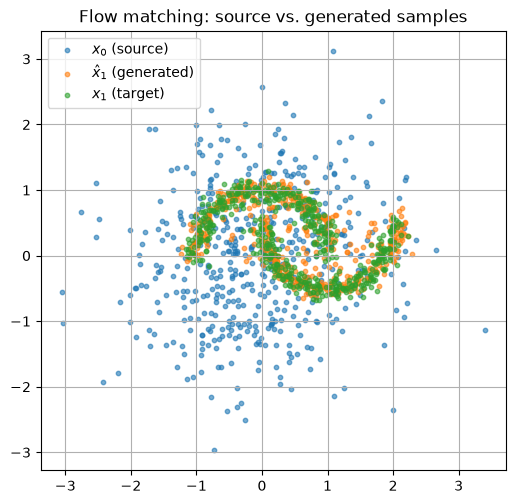

In [25]:
# Visualize x0 and x1_hat
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x0[:, 0], x0[:, 1], s=10, alpha=0.6, label=r"$x_0$ (source)")
ax.scatter(x1_hat[:, 0], x1_hat[:, 1], s=10, alpha=0.6, label=r"$\hat{x}_1$ (generated)")
ax.scatter(x1[:, 0], x1[:, 1], s=10, alpha=0.6, label=r"$x_1$ (target)")
ax.set_aspect("equal")
ax.legend()
ax.grid()
ax.set_title("Flow matching: source vs. generated samples")
plt.show()